In [1]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob
import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *
from alvra_tools.alvra_widgets import Rebin_widget
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [2]:
pgroup = 'p23084'
runlist = [176, 177, 178]
#runlist = np.arange(73, 84)

data, meta = merge_multiple_runs(pgroup, runlist)

Processing run 176


100%|██████████| 11/11 [00:05<00:00,  2.03it/s]


Processing run 177


100%|██████████| 11/11 [00:05<00:00,  2.01it/s]


Processing run 178


100%|██████████| 11/11 [00:05<00:00,  2.01it/s]


In [3]:
ui, out = Rebin_widget(data=data)

display(ui)

In [104]:
### --- To run manually instead of ui --- ###

# base_params = {'izero': 'diode2', 'quantile': 0.7, 'TT': '126', 'YAGscan': False, 'withTT': False}
# meta_params = {'signal1': 'diode1', 'signal2': 'diode2'}

# results1 = Rebin_with_scanvar_and_filter(signal='diode1', data=data, **base_params)
# #results2 = Rebin_with_scanvar_and_filter(signal='diode2', data=data, **base_params)
# out['signal1'] = {"results": results1, "params": base_params, "which": 'diode1'}
# #out['signal2'] = {"results": results2, "params": base_params, "which": 'diode2'}

In [4]:
data_plot1 = out["signal1"]
data_plot2 = out["signal2"]

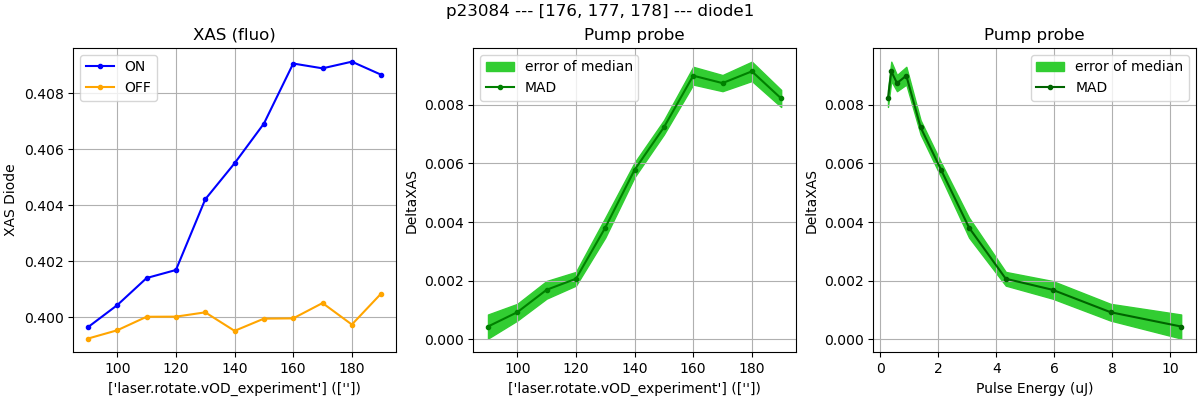

In [5]:
paramsFit = np.load('/sf/alvra/data/{}/work/alvra_beamline_scripts/fitvalues.npy'.format(pgroup))

fig, axes = plotter.fluence_scans(data_plot1, meta, paramsFit, errbars=False)
#fig, axes = plotter.fluence_scans(data_plot2, meta, paramsFit)
